In [ ]:
import sys
!{sys.executable} -m pip install /content/GraphHDBSCAN.zip

Processing ./GraphHDBSCAN_with_fixed_min_cluster_size_v0.2.8.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.2/624.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
from coresg_graphhdbscan import GraphCoreSGHDBSCAN

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
import scanpy as sc
adata =  sc.read_h5ad("/content/T_cells_CiteSeq_GEX_processed.h5ad") #file path
count_matrix = adata.X #cells as rows and genes as columns
true_labels = adata.obs['cell_labels'] #cell labels from config

In [ ]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,6),
    sim_graph_method="sc_umap",
    n_neighbors=7,
    no_noise=True,
    metric="hybrid_euclidean_cosine",
    min_cluster_size=55,
)


In [5]:
g.fit(adata.X)

[CORE-SG] (precomputed) CORE-SG graph has 20841 edges
[CORE-SG] m= 2: MST+tree+labels in 0.2518s
[CORE-SG] m= 3: MST+tree+labels in 0.2343s
[CORE-SG] m= 4: MST+tree+labels in 0.2237s
[CORE-SG] m= 5: MST+tree+labels in 0.2312s


GraphCoreSGHDBSCAN(min_samples_list=[2, 3, 4, 5], metric='euclidean', eps=1e-12, min_cluster_size=55, X_=None, N_=None, D_=None, core_={}, kmax_=None, edges_ut_=None, idx_with_self_=None, dst_with_self_=None, idx_no_self_=None, dst_no_self_=None, A_knn_=None, msts_={}, mst_times_={}, models_={}, times_={})

In [7]:
g.interactive_condensed_tree()

SelectionSlider(continuous_update=False, description='m', layout=Layout(width='500px'), options=(2, 3, 4, 5), …

<Axes: title={'center': 'Condensed Tree for m = 4'}, ylabel='$\\lambda$ value'>

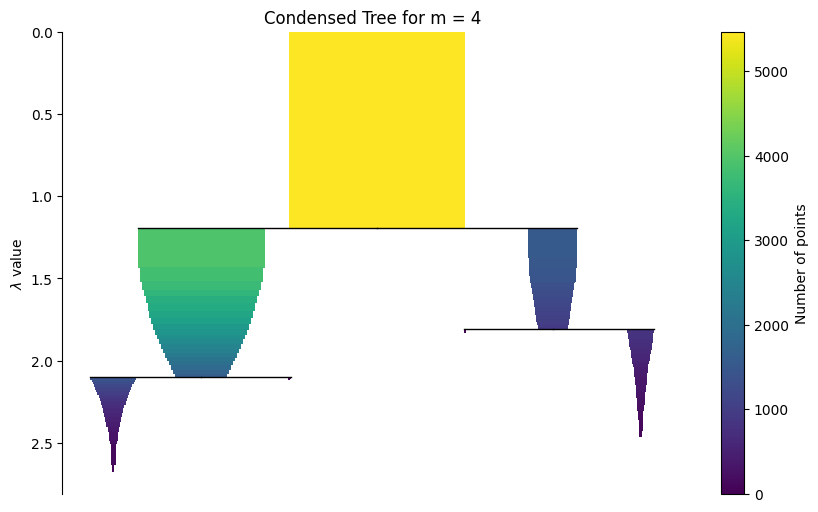

In [9]:
g.plot_condensed_tree(4)